LSTM-AE ANOMALY DETECTION - MELTING TWIN (SYNTHETIC DATA)

[1/6] Generating synthetic furnace data...
Normal data: 604800 readings
Degradation data: 86400 readings

[2/6] Preprocessing data...
Normal sequences: (604771, 30, 6)
Degradation sequences: (86371, 30, 6)
Training sequences: (483816, 30, 6)
Validation sequences: (120955, 30, 6)

[3/6] Building LSTM Autoencoder...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 30, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 6)          │           774 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,254 (708.02 KB)

 Trainable params: 181,254 (708.02 KB)

 Non-trainable params: 0 (0.00 B)


[4/6] Training LSTM-AE...
Epoch 1/100
7560/7560 ━━━━━━━━━━━━━━━━━━━━ 118s 15ms/step - loss: 0.8557 - val_loss: 0.8296 - learning_rate: 0.0010
Epoch 2/100
7560/7560 ━━━━━━━━━━━━━━━━━━━━ 142s 15ms/step - loss: 0.8223 - val_loss: 0.8068 - learning_rate: 0.0010
Epoch 3/100
7560/7560 ━━━━━━━━━━━━━━━━━━━━ 134s 18ms/step - loss: 0.8090 - val_loss: 0.7978 - learning_rate: 0.0010
Epoch 4/100
7560/7560 ━━━━━━━━━━━━━━━━━━━━ 116s 15ms/step - loss: 0.8032 - val_loss: 0.7886 - learning_rate: 0.0010
Epoch 5/100
7560/7560 ━━━━━━━━━━━━━━━━━━━━ 114s 15ms/step - loss: 0.7980 - val_loss: 0.7847 - learning_rate: 0.0010
Epoch 6/100
7560/7560 ━━━━━━━━━━━━━━━━━━━━ 113s 15ms/step - loss: 0.7950 - val_loss: 0.7833 - learning_rate: 0.0010
Epoch 7/100
7560/7560 ━━━━━━━━━━━━━━━━━━━━ 112s 15ms/step - loss: 0.7909 - val_loss: 0.7800 - learning_rate: 0.0010
Epoch 8/100
7560/7560 ━━━━━━━━━━━━━━━━━━━━ 112s 15ms/step - loss: 0.7900 - val_loss: 0.7748 - learning_rate: 0.0010
Epoch 9/100
7560/7560 ━━━━━━━━━━━━━━━━━━━━ 11

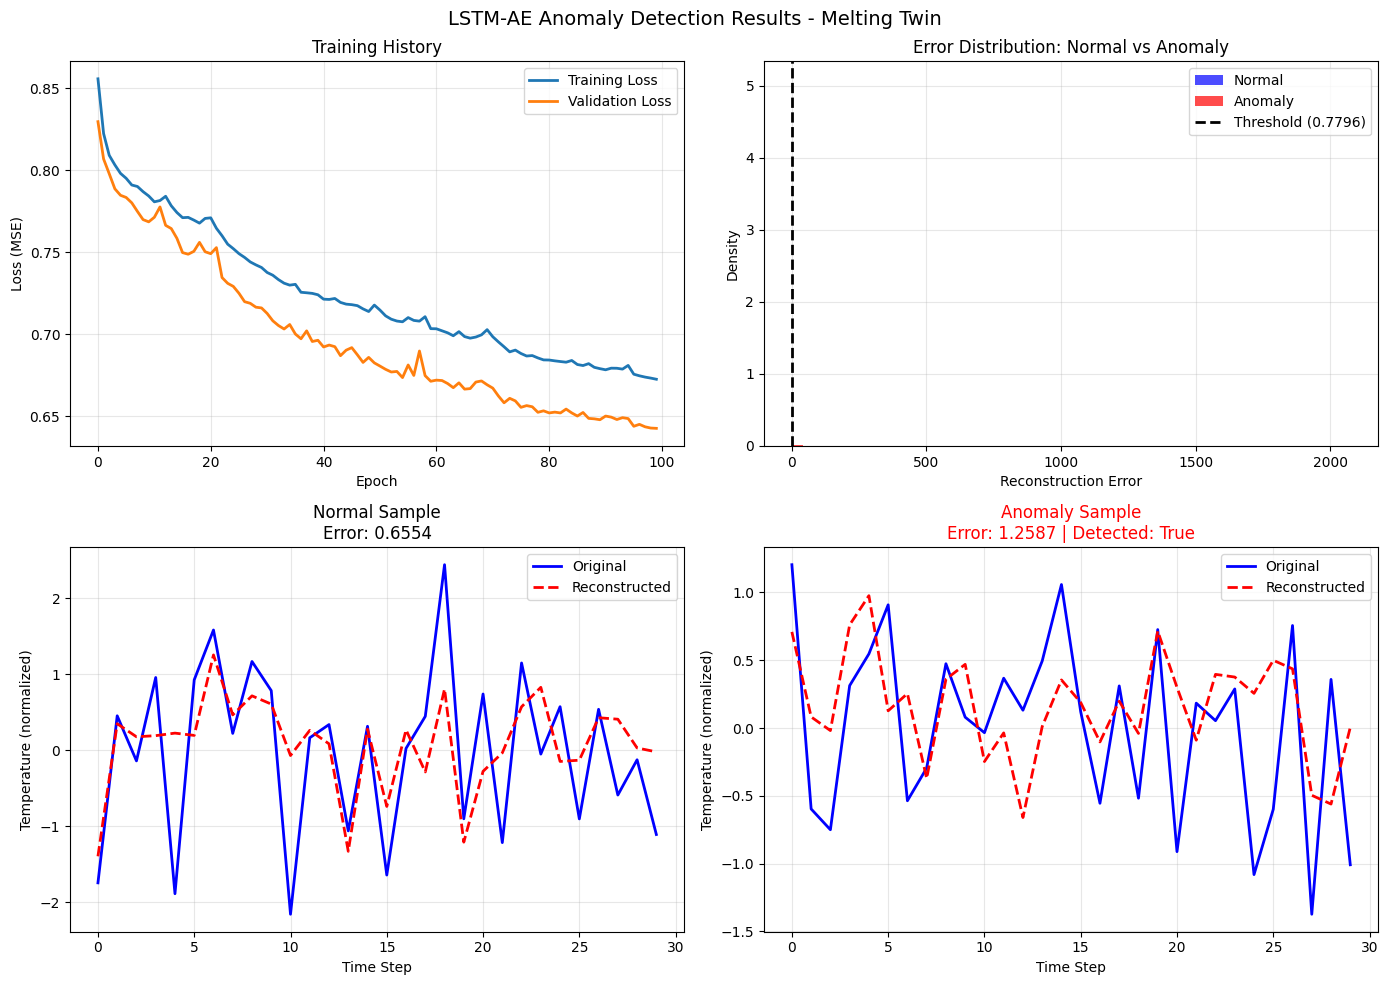


FINAL RESULTS SUMMARY
Training samples: 483816
Validation samples: 120955
Anomaly samples tested: 86371
Anomaly threshold: 0.779624
Detection rate: 99.6%
False positive rate: 5.1%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Results downloaded to your computer!

🎉 DONE! Your LSTM-AE anomaly detector is ready for the Melting Twin!


<Figure size 640x480 with 0 Axes>

In [3]:
# ============================================================
# COMPLETE LSTM-AE ANOMALY DETECTION FOR MELTING TWIN
# Google Colab Implementation - One-Cell Solution
# ============================================================

# Install any missing libraries
!pip install -q numpy pandas matplotlib seaborn tensorflow scikit-learn tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import joblib
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("LSTM-AE ANOMALY DETECTION - MELTING TWIN (SYNTHETIC DATA)")
print("=" * 70)

# ============================================================
# PART 1: GENERATE SYNTHETIC FURNACE DATA
# ============================================================
print("\n[1/6] Generating synthetic furnace data...")

np.random.seed(42)

def generate_normal_operation(days=14, freq_sec=2):
    """Generate normal furnace operation data"""
    readings_per_day = int(24 * 3600 / freq_sec)
    total_readings = days * readings_per_day

    timestamps = [datetime(2026, 3, 1) + timedelta(seconds=i*freq_sec)
                  for i in range(total_readings)]

    data = {
        'timestamp': timestamps,
        'melt_temp': np.random.normal(1382, 3, total_readings),
        'power_kw': np.random.normal(847, 8, total_readings),
        'vibration_g': np.random.normal(0.031, 0.002, total_readings),
        'lining_health': np.random.normal(0.78, 0.005, total_readings),
        'humidity': np.random.normal(58, 2, total_readings),
        'ambient_temp': np.random.normal(29, 1, total_readings)
    }
    return pd.DataFrame(data)

def generate_degradation_operation(hours=48, freq_sec=2):
    """Generate degrading furnace data (anomaly)"""
    readings_per_hour = int(3600 / freq_sec)
    total_readings = hours * readings_per_hour

    timestamps = [datetime(2026, 3, 15) + timedelta(seconds=i*freq_sec)
                  for i in range(total_readings)]

    t = np.linspace(0, hours, total_readings)
    degradation_factor = np.maximum(0, (t - 24) / 24)

    data = {
        'timestamp': timestamps,
        'melt_temp': 1382 + 100 * degradation_factor + np.random.normal(0, 2, total_readings),
        'power_kw': 847 + 150 * degradation_factor + np.random.normal(0, 5, total_readings),
        'vibration_g': 0.031 + 0.06 * degradation_factor + np.random.normal(0, 0.003, total_readings),
        'lining_health': np.clip(0.78 - 0.5 * degradation_factor + np.random.normal(0, 0.01, total_readings), 0.2, 0.8),
        'humidity': np.random.normal(58, 3, total_readings),
        'ambient_temp': np.random.normal(29, 1, total_readings)
    }
    return pd.DataFrame(data)

# Generate data
normal_df = generate_normal_operation(days=14)
degrade_df = generate_degradation_operation(hours=48)

print(f"Normal data: {len(normal_df)} readings")
print(f"Degradation data: {len(degrade_df)} readings")

# ============================================================
# PART 2: PREPROCESS DATA
# ============================================================
print("\n[2/6] Preprocessing data...")

feature_columns = ['melt_temp', 'power_kw', 'vibration_g', 'lining_health', 'humidity', 'ambient_temp']
normal_features = normal_df[feature_columns].values
degrade_features = degrade_df[feature_columns].values

# Normalize using ONLY normal data
scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal_features)
degrade_scaled = scaler.transform(degrade_features)

# Create sequences
SEQ_LENGTH = 30

def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i+seq_length])
    return np.array(sequences)

normal_seq = create_sequences(normal_scaled, SEQ_LENGTH)
degrade_seq = create_sequences(degrade_scaled, SEQ_LENGTH)

print(f"Normal sequences: {normal_seq.shape}")
print(f"Degradation sequences: {degrade_seq.shape}")

# Split normal sequences into train and validation
X_train, X_val = train_test_split(normal_seq, test_size=0.2, random_state=42)
print(f"Training sequences: {X_train.shape}")
print(f"Validation sequences: {X_val.shape}")

# ============================================================
# PART 3: BUILD LSTM-AE MODEL
# ============================================================
print("\n[3/6] Building LSTM Autoencoder...")

def build_lstm_ae(input_shape, latent_dim=32):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.LSTM(128, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    encoded = layers.LSTM(latent_dim, return_sequences=False)(x)

    # Decoder
    x = layers.RepeatVector(input_shape[0])(encoded)
    x = layers.LSTM(latent_dim, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(128, return_sequences=True)(x)
    decoded = layers.TimeDistributed(layers.Dense(input_shape[1]))(x)

    model = models.Model(inputs, decoded)
    model.compile(optimizer='adam', loss='mse')
    return model

input_shape = (SEQ_LENGTH, normal_seq.shape[2])
model = build_lstm_ae(input_shape)
model.summary()

# ============================================================
# PART 4: TRAIN THE MODEL
# ============================================================
print("\n[4/6] Training LSTM-AE...")

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_train, X_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# ============================================================
# PART 5: CALCULATE THRESHOLD & TEST ON ANOMALIES
# ============================================================
print("\n[5/6] Calculating threshold and testing on anomalies...")

# Calculate reconstruction errors for training
train_recon = model.predict(X_train, verbose=0)
train_errors = np.mean(np.square(X_train - train_recon), axis=(1, 2))
threshold = np.percentile(train_errors, 95)
print(f"Anomaly threshold (95th percentile): {threshold:.6f}")

# Test on anomalies
anomaly_recon = model.predict(degrade_seq, verbose=0)
anomaly_errors = np.mean(np.square(degrade_seq - anomaly_recon), axis=(1, 2))

detected = (anomaly_errors > threshold).sum()
detection_rate = detected / len(anomaly_errors) * 100
print(f"\nAnomaly samples tested: {len(anomaly_errors)}")
print(f"Detected as anomalies: {detected}")
print(f"Detection rate: {detection_rate:.1f}%")

# False positive rate
val_recon = model.predict(X_val, verbose=0)
val_errors = np.mean(np.square(X_val - val_recon), axis=(1, 2))
false_positives = (val_errors > threshold).sum()
false_positive_rate = false_positives / len(val_errors) * 100
print(f"False positive rate: {false_positive_rate:.1f}%")

# ============================================================
# PART 6: VISUALIZATION
# ============================================================
print("\n[6/6] Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LSTM-AE Anomaly Detection Results - Melting Twin', fontsize=14)

# Plot 1: Training History
ax1 = axes[0, 0]
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training History')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Error Distribution
ax2 = axes[0, 1]
ax2.hist(train_errors, bins=50, alpha=0.7, color='blue', label='Normal', density=True)
ax2.hist(anomaly_errors, bins=50, alpha=0.7, color='red', label='Anomaly', density=True)
ax2.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')
ax2.set_xlabel('Reconstruction Error')
ax2.set_ylabel('Density')
ax2.set_title('Error Distribution: Normal vs Anomaly')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Normal Sample Reconstruction
ax3 = axes[1, 0]
sample_idx = np.random.randint(0, len(X_val))
original = X_val[sample_idx]
reconstructed = val_recon[sample_idx]
ax3.plot(original[:, 0], 'b-', linewidth=2, label='Original')
ax3.plot(reconstructed[:, 0], 'r--', linewidth=2, label='Reconstructed')
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Temperature (normalized)')
ax3.set_title(f'Normal Sample\nError: {val_errors[sample_idx]:.4f}')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Anomaly Sample Reconstruction
ax4 = axes[1, 1]
sample_idx = np.random.randint(0, len(degrade_seq))
original = degrade_seq[sample_idx]
reconstructed = anomaly_recon[sample_idx]
error_val = anomaly_errors[sample_idx]
color = 'red' if error_val > threshold else 'green'
ax4.plot(original[:, 0], 'b-', linewidth=2, label='Original')
ax4.plot(reconstructed[:, 0], 'r--', linewidth=2, label='Reconstructed')
ax4.set_xlabel('Time Step')
ax4.set_ylabel('Temperature (normalized)')
ax4.set_title(f'Anomaly Sample\nError: {error_val:.4f} | Detected: {error_val > threshold}', color=color)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('anomaly_detection_results.png', dpi=150)
plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Anomaly samples tested: {len(anomaly_errors)}")
print(f"Anomaly threshold: {threshold:.6f}")
print(f"Detection rate: {detection_rate:.1f}%")
print(f"False positive rate: {false_positive_rate:.1f}%")
print("=" * 70)

# Download results (optional)
from google.colab import files
plt.savefig('anomaly_results.png')
files.download('anomaly_results.png')
print("\n✅ Results downloaded to your computer!")

print("\n🎉 DONE! Your LSTM-AE anomaly detector is ready for the Melting Twin!")